In [103]:
import seaborn as sns
import torch
import numpy as np
import hashlib
import matplotlib.pyplot as plt 
import os

In [104]:
ckpt_path = '/home/spanchavati/eegfmchallenge/lightning_logs/v2_lejepa_pretraining_global_proj/version_0/checkpoints/last.ckpt'
ckpt_hash = hashlib.md5(str(ckpt_path).encode()).hexdigest()[:12]
# ckpt_hash = '0de96d9c9e44'

In [105]:
embedding_to_analyze = f"cache/lejepa_embeddings/abnormal_clinical_{ckpt_hash}_{'297d02079cf4'}_train_v2.npz"

# np.load(embedding_to_analyze)
data = np.load(embedding_to_analyze)

In [114]:
embeddings = data['embeddings']


labels = data['labels']
embeddings_tensor = torch.tensor(embeddings)


In [115]:
labels

array([0, 0, 0, ..., 1, 1, 1])

In [117]:
labram_data['labels'].shape

torch.Size([2717])

In [119]:
labram_embedding_abnormal = '/radraid2/spanchavati/EEGBench/data/embedding_cache/abnormal_clinical_0ff3d32e0c73bc1fc970c816523deea488eef267.pt'
labram_data = torch.load(labram_embedding_abnormal)

#we need to subsample to match the number of samples
labram_embedding = labram_data['features'][:embeddings_tensor.shape[0], :]
labram_labels = labram_data['labels'][:embeddings_tensor.shape[0]]

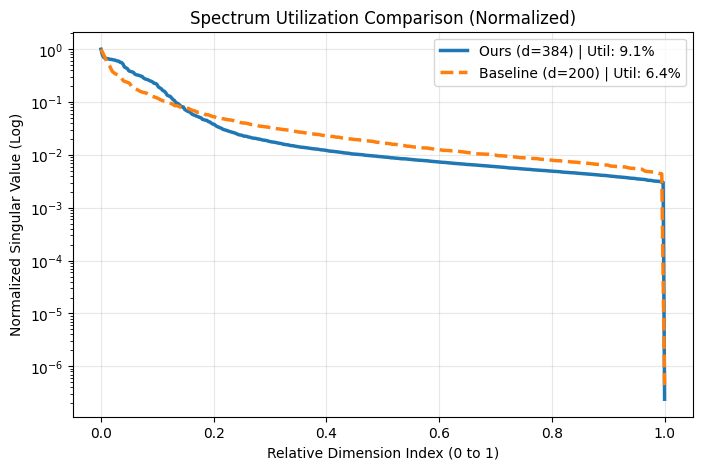

In [120]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def get_spectrum_data(z):
    """
    Returns normalized x (0 to 1) and normalized singular values (log scale).
    """
    # 1. Compute SVD
    z = z - z.mean(dim=0, keepdim=True)
    _, S, _ = torch.linalg.svd(z, full_matrices=False)
    S = S.cpu().numpy()
    
    # 2. Compute Metric: Fractional Effective Rank
    # p is the probability distribution of variance
    # probability over variance
    p = (S ** 2) / np.sum(S ** 2)

    entropy = -np.sum(p * np.log(p + 1e-12))
    eff_rank = np.exp(entropy)

    dim = min(z.shape)
    utilization = eff_rank / dim
    
    # 3. Prepare Plot Data
    # Normalize X-axis to [0, 1]
    x_norm = np.linspace(0, 1, len(S))
    
    # Normalize Y-axis (Singular Values) so max is 1.0 (Log scale ready)
    # This removes scale differences due to embedding norm
    s_norm = S / S.max()
    
    return x_norm, s_norm, utilization


z_ours = embeddings_tensor


z_baseline = labram_embedding

# Get Data
x_ours, y_ours, util_ours = get_spectrum_data(z_ours)
x_base, y_base, util_base = get_spectrum_data(z_baseline)

# --- Plotting ---

plt.figure(figsize=(8, 5))

# Plot LeJEPA
plt.plot(x_ours, y_ours, label=f"Ours (d={z_ours.shape[1]}) | Util: {util_ours:.1%}", linewidth=2.5)

# Plot Baseline
plt.plot(x_base, y_base, label=f"Baseline (d={z_baseline.shape[1]}) | Util: {util_base:.1%}", linewidth=2.5, linestyle="--")

plt.yscale('log')
plt.xlabel("Relative Dimension Index (0 to 1)")
plt.ylabel("Normalized Singular Value (Log)")
plt.title("Spectrum Utilization Comparison (Normalized)")
plt.legend()
plt.grid(True, which="major", alpha=0.3)
plt.show()

In [121]:
# from sklearn.manifold import TSNE
# from sklearn.decomposition import PCA
# decomp = PCA(n_components=2, random_state=42)
# embeddings_2d = decomp.fit_transform(embeddings)
# sns.scatterplot(x=embeddings_2d[:,0], y=embeddings_2d[:,1], hue=labels, palette="Set1",s =5)


In [122]:
# from sklearn.manifold import TSNE
# from sklearn.decomposition import PCA
# decomp = PCA(n_components=2, random_state=42)
# embeddings_2d = decomp.fit_transform(labram_embedding.numpy())
# sns.scatterplot(x=embeddings_2d[:,0], y=embeddings_2d[:,1], hue=labram_labels, palette="Set1",s =5)


In [123]:
embeddings.shape

(2174, 384)

In [124]:
labram_labels.shape

torch.Size([2174])

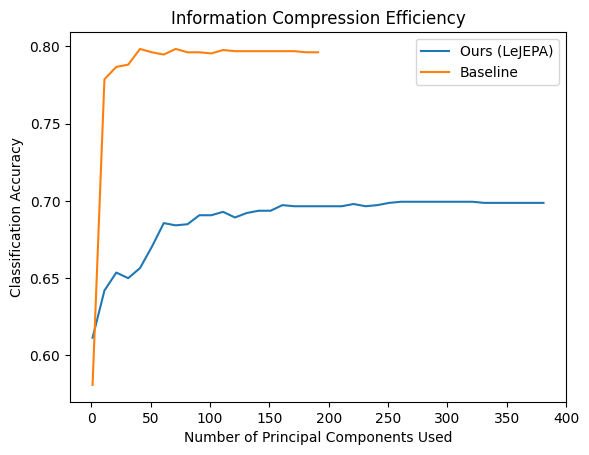

In [125]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

def cumulative_accuracy_curve(embeddings, labels, step=10):
    # 1. PCA to sort dimensions by variance (importance)
    pca = PCA()

    train_embeddings, test_embeddings = embeddings[:800, :], embeddings[800:, :]
    train_labels, test_labels = labels[:800], labels[800:]



    z_pca = pca.fit_transform(train_embeddings) # shape: [N, D]
    
    accuracies = []
    num_components = range(1, z_pca.shape[1] + 1, step)
    
    # 2. Iteratively train on top-k components
    for k in num_components:
        # Take only top k columns
        X_k = z_pca[:, :k]
        X_k_test = pca.transform(test_embeddings)[:, :k]
        
        # Simple Linear Probe (Logistic Regression)
        clf = LogisticRegression(max_iter=1000)
        clf.fit(X_k, train_labels) 
        # Note: In a real paper, split this into train/test!
        # This is just illustrative of the curve shape.
        acc = clf.score(X_k_test, test_labels)
        accuracies.append(acc)
        
    return list(num_components), accuracies

# Run for both
k_ours, acc_ours = cumulative_accuracy_curve(embeddings, labels)
k_base, acc_base = cumulative_accuracy_curve(labram_embedding.numpy(), labram_labels.numpy())

# Plot
plt.plot(k_ours, acc_ours, label="Ours (LeJEPA)")
plt.plot(k_base, acc_base, label="Baseline")
plt.xlabel("Number of Principal Components Used")
plt.ylabel("Classification Accuracy")
plt.title("Information Compression Efficiency")
plt.legend()
plt.show()

In [127]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

def make_ks(D):
    return list(range(1, 51)) + list(range(50, D + 1, 20))

def probe_weighted_cumulative_curve(
    embeddings, labels, ks, C=1.0
):
    # ---- train / test split ----
    X_train, X_test = embeddings[:800], embeddings[800:]
    y_train, y_test = labels[:800], labels[800:]

    # ---- standardize ----
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # ---- full probe ----
    clf_full = LogisticRegression(
        max_iter=5000,
        C=C,
        penalty="l2",
        solver="lbfgs"
    )
    clf_full.fit(X_train, y_train)

    # ---- dimension importance ----
    W = clf_full.coef_                # [n_classes, D]
    importance = np.linalg.norm(W, axis=0)
    sorted_dims = np.argsort(importance)[::-1]

    accs = []

    for k in ks:
        dims_k = sorted_dims[:k]

        clf_k = LogisticRegression(
            max_iter=5000,
            C=C,
            penalty="l2",
            solver="lbfgs"
        )
        clf_k.fit(X_train[:, dims_k], y_train)
        accs.append(clf_k.score(X_test[:, dims_k], y_test))

    return np.array(accs)


In [128]:
def random_subspace_curve(
    embeddings, labels, ks, n_trials=20, C=1.0, seed=0
):
    rng = np.random.default_rng(seed)

    # ---- train / test split ----
    X_train, X_test = embeddings[:800], embeddings[800:]
    y_train, y_test = labels[:800], labels[800:]

    # ---- standardize ----
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    N, D = X_train.shape

    mean_acc = []
    std_acc = []

    for k in ks:
        accs = []
        for _ in range(n_trials):
            dims = rng.choice(D, size=k, replace=False)

            clf = LogisticRegression(
                max_iter=5000,
                C=C,
                penalty="l2",
                solver="lbfgs"
            )
            clf.fit(X_train[:, dims], y_train)
            accs.append(clf.score(X_test[:, dims], y_test))

        mean_acc.append(np.mean(accs))
        std_acc.append(np.std(accs))

    return np.array(mean_acc), np.array(std_acc)


In [ ]:
# --- OURS ---
D_ours = embeddings.shape[1]
ks_ours = make_ks(D_ours)
x_ours = np.array(ks_ours) / D_ours

acc_ours = probe_weighted_cumulative_curve(
    embeddings, labels, ks_ours
)
rand_ours_mean, rand_ours_std = random_subspace_curve(
    embeddings, labels, ks_ours
)

# --- BASELINE ---
D_base = labram_embedding.shape[1]
ks_base = make_ks(D_base)
x_base = np.array(ks_base) / D_base

acc_base = probe_weighted_cumulative_curve(
    labram_embedding.numpy(), labram_labels.numpy(), ks_base
)
rand_base_mean, rand_base_std = random_subspace_curve(
    labram_embedding.numpy(), labram_labels.numpy(), ks_base
)

array([0.53205968, 0.55298399, 0.55665939, 0.58471616, 0.56535662,
       0.5842067 , 0.57958515, 0.59443231, 0.60050946, 0.60098253,
       0.60669578, 0.61124454, 0.60873362, 0.61597525, 0.62503639,
       0.61466521, 0.62216157, 0.6290393 , 0.62751092, 0.63009461,
       0.63155022, 0.6319869 , 0.63886463, 0.63882824, 0.63693595,
       0.64363173, 0.64981805, 0.64556041, 0.6466885 , 0.65025473,
       0.65425764, 0.65032751, 0.65225619, 0.65287482, 0.65898836,
       0.65891557, 0.65425764, 0.65491266, 0.66404658, 0.65997089,
       0.66313683, 0.66240902, 0.66411936, 0.66826783, 0.66659389,
       0.67201601, 0.67347162, 0.66637555, 0.66695779, 0.66994178,
       0.67037846, 0.67838428, 0.69148472, 0.69199418, 0.69690684,
       0.69916303, 0.70407569, 0.70647744, 0.70884279, 0.70946143,
       0.71088064, 0.71124454, 0.71502911, 0.71259098, 0.71422853,
       0.71546579, 0.71572052])

bci_Five Fingers MI_0de96d9c9e44_b33083f9601a_val_v2.npz


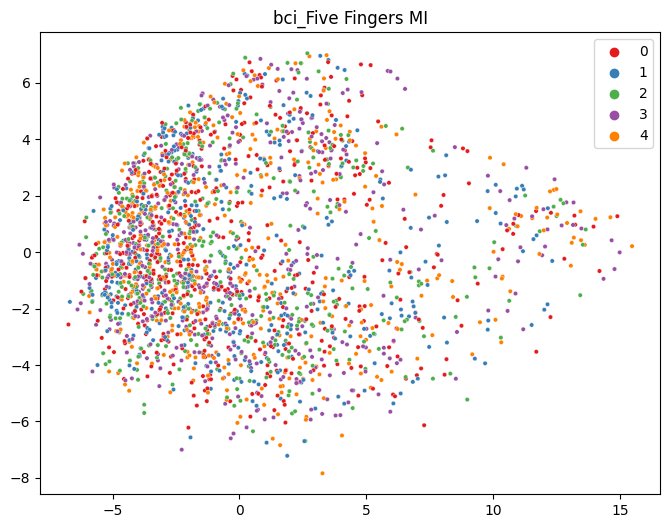

sleep_stages_clinical_0de96d9c9e44_ca568cc88166_val_v2.npz
bci_Left Hand vs Right Hand vs Feet vs Tongue MI_0de96d9c9e44_2a8c155b93ce_train_v2.npz


<Figure size 800x600 with 0 Axes>

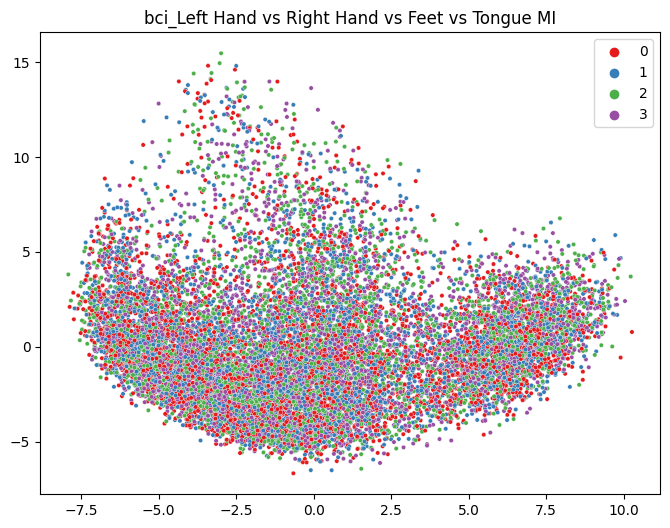

parkinsons_clinical_0de96d9c9e44_a6ca557769a8_val_v2.npz


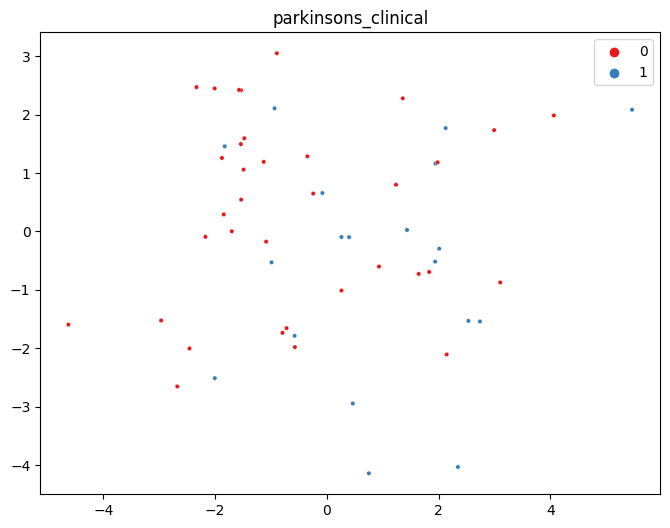

sleep_stages_clinical_0de96d9c9e44_ca568cc88166_train_v2.npz
epilepsy_clinical_0de96d9c9e44_37e74995a1ee_val_v2.npz


<Figure size 800x600 with 0 Axes>

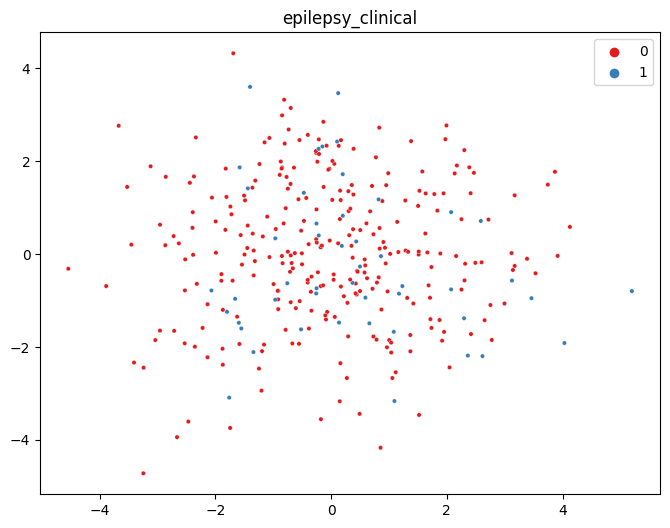

ocd_clinical_0de96d9c9e44_44d447d52ee3_train_v2.npz


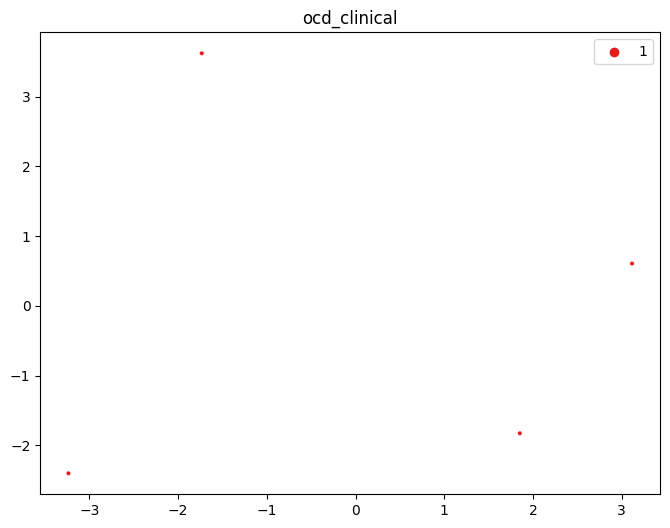

bci_Five Fingers MI_0de96d9c9e44_cd7336ab77b1_train_v2.npz


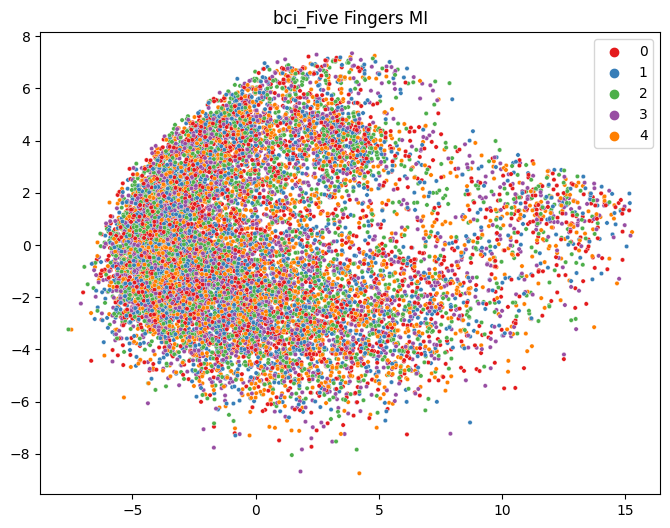

multiclass_artifact_clinical_0de96d9c9e44_8af820613c70_train_v2.npz
seizure_clinical_0de96d9c9e44_c48d28b41204_train_v2.npz
epilepsy_clinical_0de96d9c9e44_37e74995a1ee_train_v2.npz


<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

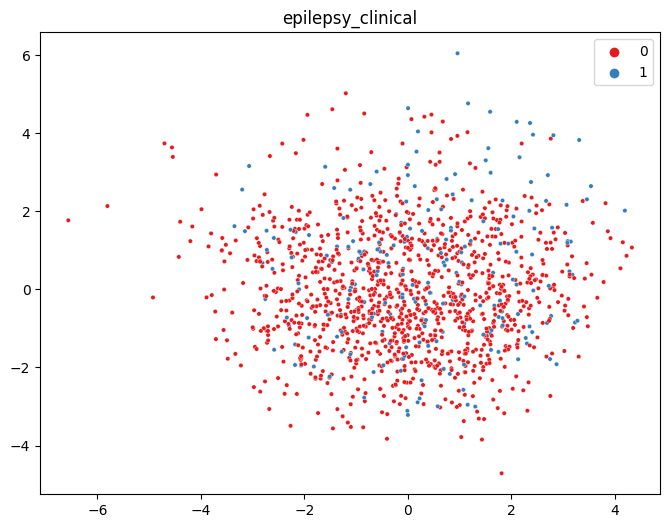

binary_artifact_clinical_0de96d9c9e44_1ae0af45a5c8_train_v2.npz
bci_Right Hand vs Feet MI_0de96d9c9e44_8d9cfc0ad168_train_v2.npz


<Figure size 800x600 with 0 Axes>

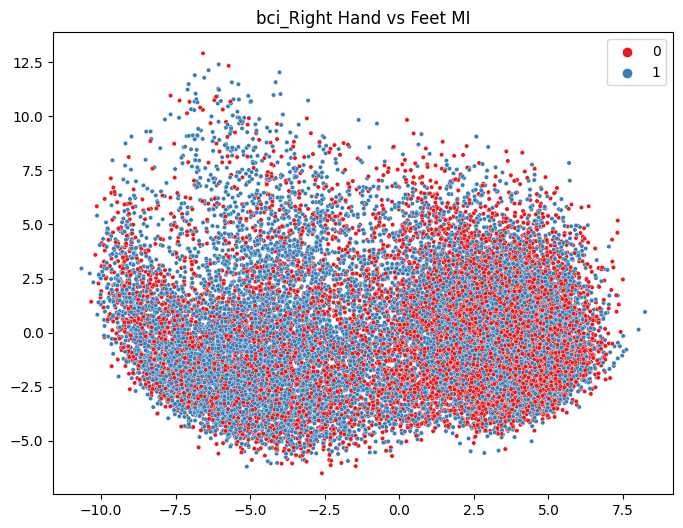

abnormal_clinical_0de96d9c9e44_297d02079cf4_val_v2.npz


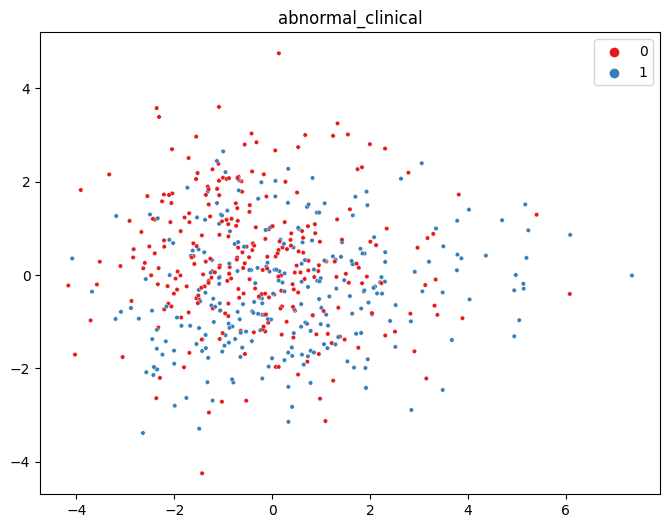

mtbi_clinical_0de96d9c9e44_d3f1a38ef343_train_v2.npz


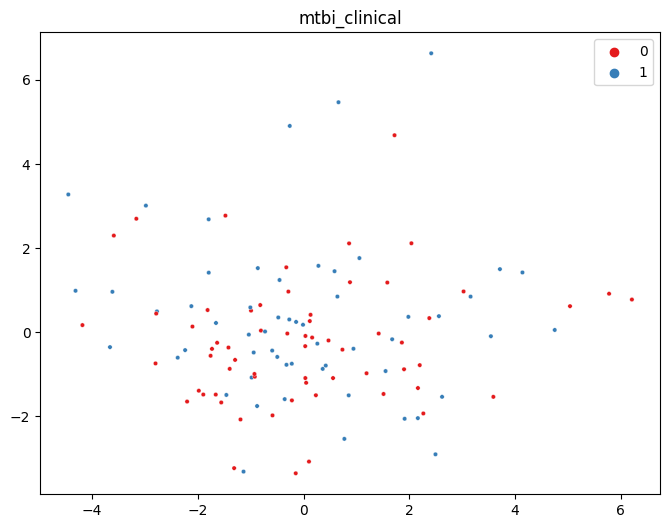

mtbi_clinical_0de96d9c9e44_d3f1a38ef343_val_v2.npz


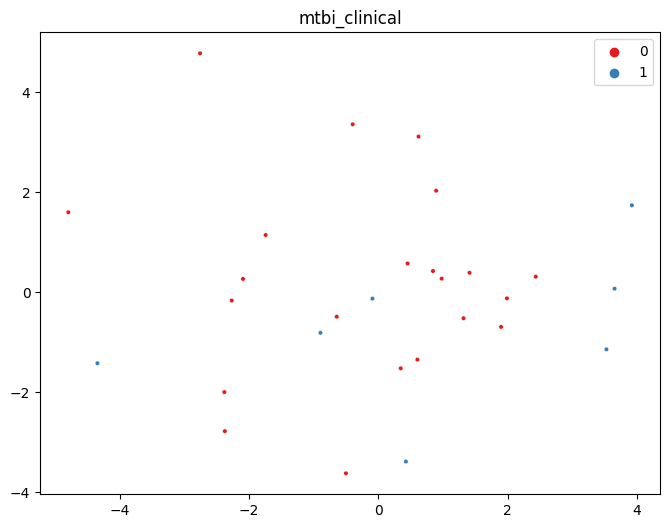

abnormal_clinical_0de96d9c9e44_297d02079cf4_train_v2.npz


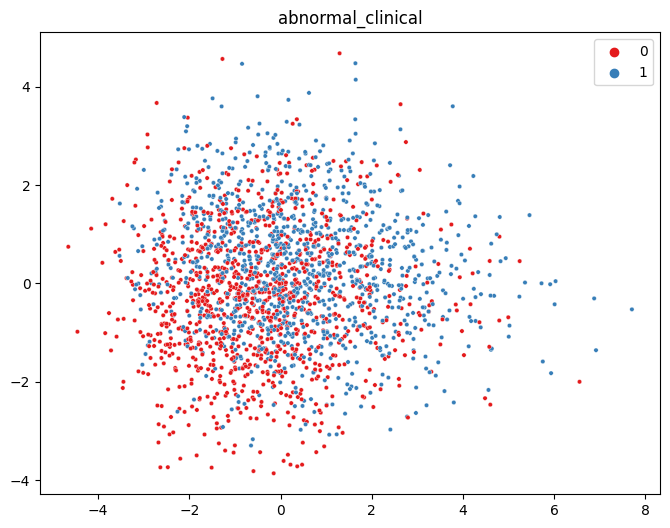

bci_Left Hand vs Right Hand vs Feet vs Tongue MI_0de96d9c9e44_f658729c5180_val_v2.npz


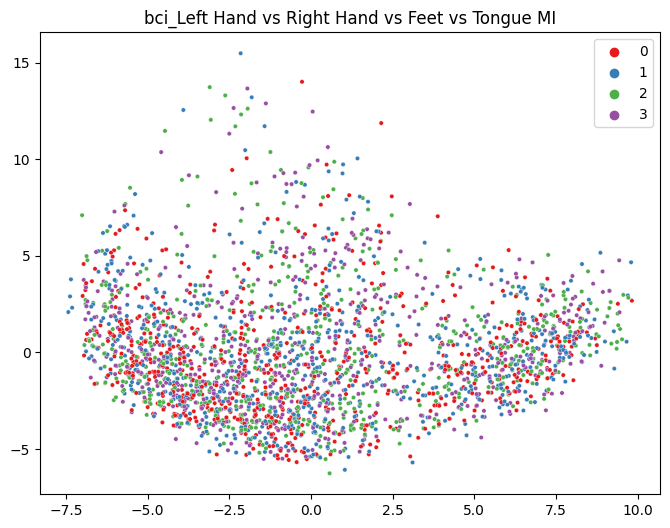

binary_artifact_clinical_0de96d9c9e44_1ae0af45a5c8_val_v2.npz
schizophrenia_clinical_0de96d9c9e44_0901c4f19a6a_train_v2.npz


<Figure size 800x600 with 0 Axes>

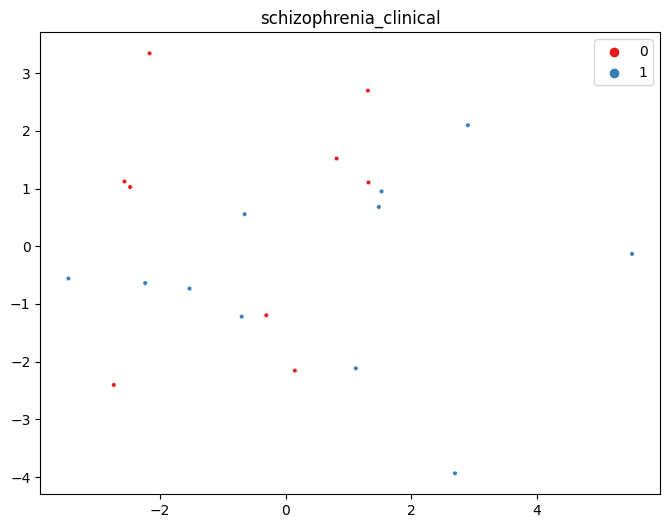

bci_Right Hand vs Feet MI_0de96d9c9e44_ad6e4553b5f0_val_v2.npz


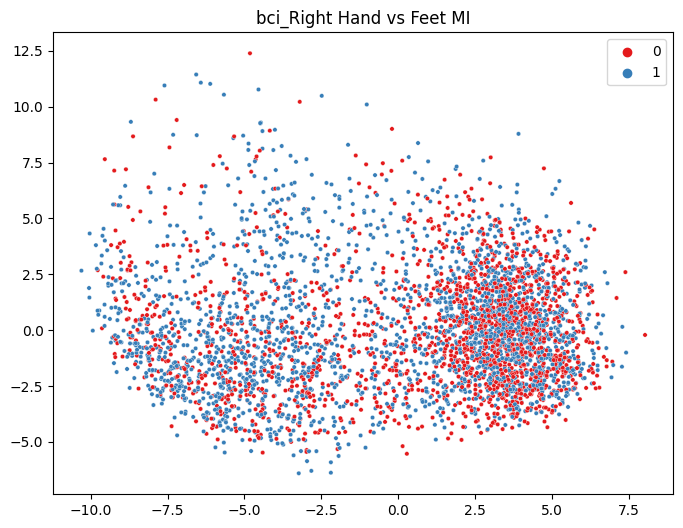

parkinsons_clinical_0de96d9c9e44_a6ca557769a8_train_v2.npz


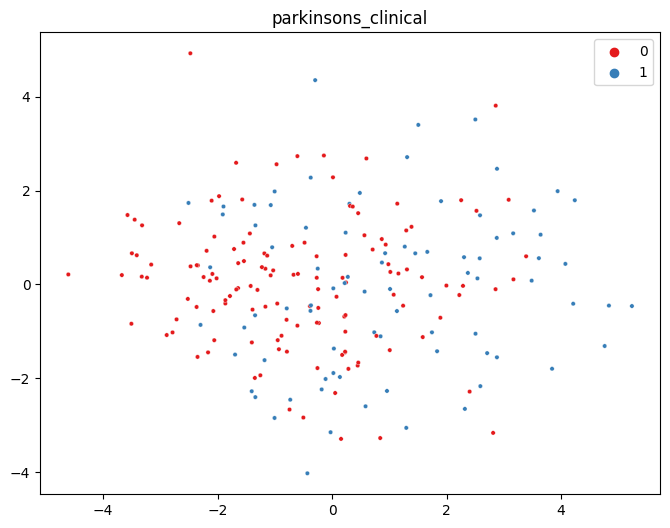

seizure_clinical_0de96d9c9e44_c48d28b41204_val_v2.npz
multiclass_artifact_clinical_0de96d9c9e44_8af820613c70_val_v2.npz
schizophrenia_clinical_0de96d9c9e44_0901c4f19a6a_val_v2.npz


<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

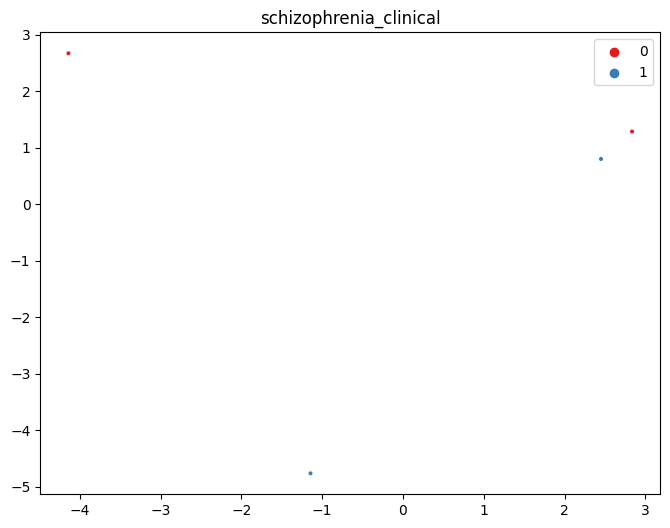

In [78]:
all_embeddings = os.listdir('cache/lejepa_embeddings/')
for emb_file in all_embeddings:
    if ckpt_hash in emb_file:
        print(emb_file)
        data = np.load(os.path.join('cache/lejepa_embeddings/', emb_file))
        embeddings = data['embeddings']
        labels = data['labels']
        decomp = PCA(n_components=2, random_state=42)
        embeddings_2d = decomp.fit_transform(embeddings)

        # if labels.sha

        try:
            plt.figure(figsize=(8,6))
            sns.scatterplot(x=embeddings_2d[:,0], y=embeddings_2d[:,1], hue=labels, palette="Set1",s =10)
            title = '_'.join(emb_file.split('_')[:2])
            plt.title(title)
            plt.show() 
        except:
            pass

In [69]:
embeddings.shape

(13417, 384)

In [70]:
embeddings.shape

(13417, 384)

In [71]:
labels.shape

(13417, 16)